## Chapter 3, P2: Scikit-Learn's GradientBoostingRegressor


Scikit-Learn’s `GradientBoostingRegressor` builds an **additive ensemble model** by sequentially fitting **regression trees** to the **negative gradient of the loss function** (for regression, typically mean squared error).

Each new tree corrects the errors of the current ensemble, allowing the model to **incrementally improve its regression performance**.

## Important Parameters

When you instantiate `GradientBoostingRegressor`, you can configure several parameters that significantly influence its behavior.

**Loss Objective Function:**
- `loss`: The loss function to be optimised. The choice of loss depends on the specifics of your regression problem, especially its **sensitivity to outliers**:  

  - `squared_error`: The default option, which stands for **least squares regression**. It minimises the MSE (L2 Loss). It's a good general-purpose loss, but **is sensitive to outliers** as an error of 4 is 16x more influential than an error of 1.  

  - `absolute_error`: Stands for **least absolute deviation**. It minimises the MAE (L1 Loss). It's more **robust to outliers** than least-squares.
  - `huber`: A combination of `ls` and `lad`. It behaves like MSE for small errors and MAE for larger errors, providing balance of sensitivity and robustnesss.
  - `quantile`: Allows for **quantile regression**. Instead of the predicting the mean, this loss is used to predict a specific quantile (e.g., the 50th percentile, which is median).

**Model Complexity & Learning:** The interaction between `n_estimators`, `learning_rate`, and `max_depth` governs the model's ability to fit the training data without overfitting.
- `learning_rate`: A float between 0.0 and 1.0 that scales the contribution of each tree. A lower learning rate requires more boosting stages to achieve the same level of training error but often results in better generalization. This is a form of regularization.  

- `n_estimators`: The number of boosting stages to perform. This is the total number of trees in the ensemble. More trees can lead to better performance on the training data, but also to overfitting if the number is too high.
- `max_depth`: The maximum depth of the individual regression estimators. The maximum depth limits the number of nodes in the tree, controlling its complexity. A smaller depth reduces variance and helps prevent overfitting.
- `subsample`: The fraction of samples to be used for fitting the individual base learners. If smaller than 1.0, this results in Stochastic Gradient Boosting, which can reduce variance and improve model generalization at the cost of increased bias.

## Practical Implementation

A simple example of using `GradientBoostingClassifier`.

In [10]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Generate a synthetic dataset
X = np.random.rand(100, 1) * 100
y = np.sin(X).ravel() + np.random.normal(0, 0.3, 100)

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# 3. Initialise the GradientBoostingRegressor with default params
gbr = GradientBoostingRegressor(random_state = 42)

# 4. Fit the model to the training data
gbr.fit(X_train, y_train)

# 5. Make predictions on the test set
y_pred = gbr.predict(X_test)

# Evaluate the model's performance
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.4f}")

Mean Squared Error: 0.5339


## Importance of understanding the parameters

Let's build a model to fit a more complex, non-linear function and visualize its predictions. We will use a slightly more configured model to see the effect of changing parameters.

In [13]:
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor

# Generate a non-linear dataset with noise
np.random.seed(0)
X = np.linspace(0, 6, 150)[:, np.newaxis]
y = np.sin(X).ravel() + np.random.normal(0, 0.5, 150)

# Instantiate and configure the model
gbr_tuned = GradientBoostingRegressor(
    n_estimators=200,      # More trees
    learning_rate=0.05,    # A smaller learning rate
    max_depth=4,           # Slightly deeper trees
    loss='squared_error',             # Standard least squares loss
    random_state=42
)

# Fit the model
gbr_tuned.fit(X, y)

# Create a smooth line for prediction visualization
X_plot = np.linspace(0, 6, 500)[:, np.newaxis]
y_plot = gbr_tuned.predict(X_plot)

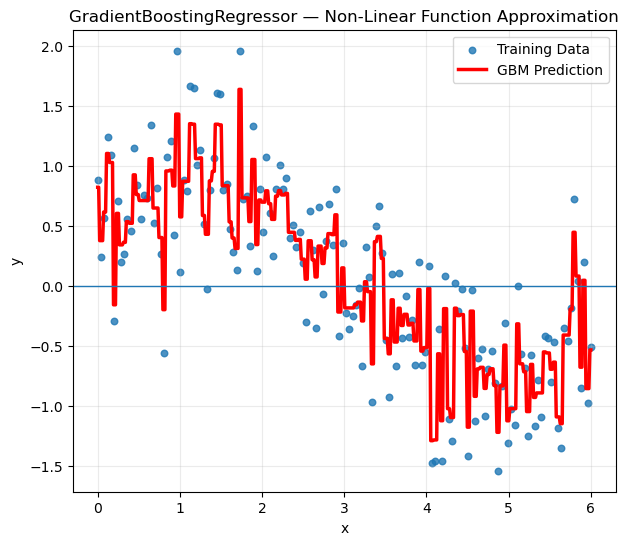

In [15]:
import matplotlib.pyplot as plt

# Create a smooth line for prediction visualisation
X_plot = np.linspace(0, 6, 500)[:, np.newaxis]
y_plot = gbr_tuned.predict(X_plot)

plt.figure(figsize=(7, 6))

# Plot training data
plt.scatter(
    X, y,
    s=22,
    alpha=0.8,
    label="Training Data"
)

# Plot GBM prediction
plt.plot(
    X_plot, y_plot,
    linewidth=2.5,
    label="GBM Prediction",
    color="red"
)

# Optional reference line
plt.axhline(0, linewidth=1)

plt.xlabel("x")
plt.ylabel("y")
plt.title("GradientBoostingRegressor — Non-Linear Function Approximation")
plt.legend()
plt.grid(alpha=0.25)

plt.show()

* The model's prediction (red line) closely follows the underlying pattern of the noisy training data (blue points), demonstrating its ability to learn complex, non-linear relationships.
* Setting a smaller learning_rate and a higher n_estimators, we encourage the model to learn the underlying pattern more gradually. The max_depth of 4 allows each tree to capture a moderate level of interaction.